# Predicting NYC Airbnb Listing Popularity
*An end-to-end ML pipeline for estimating review frequency from listing attributes using scikit-learn*


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
)

from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## Introduction

Airbnb hosts listing new properties have no historical review data to gauge expected demand. A predictive model that estimates listing popularity *before* posting could help hosts optimize pricing, descriptions, and availability settings to maximize bookings.

This project builds an end-to-end regression pipeline on the [New York City Airbnb Open Data](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) (2019, ~48K listings) to predict `reviews_per_month` as a proxy for popularity. The pipeline combines numeric scaling, one-hot encoding of 220 neighbourhoods, and TF-IDF vectorization of listing titles into a 1,232-feature representation, then benchmarks Ridge, Random Forest, HistGradientBoosting, and a Stacking ensemble.


## Problem Statement

**Goal:** Predict `reviews_per_month` for NYC Airbnb listings using only information available at the time of posting.

This is a regression task. The target variable is continuous and right-skewed, with many listings at zero. Key challenges include:
- **Data leakage:** `number_of_reviews` and `last_review` are derived from the same review data as the target and must be excluded.
- **Mixed feature types:** The dataset contains numeric, categorical, and free-text features requiring different preprocessing.
- **Skewed target:** A log-transform is needed to stabilize variance and improve model performance.


In [2]:
airbnb = pd.read_csv('data/AB_NYC_2019.csv')
airbnb.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Data Splitting


In [3]:
train_df, test_df = train_test_split(airbnb, test_size=0.3, random_state=123)

y_train = train_df["reviews_per_month"]
y_test = test_df["reviews_per_month"]
X_train = train_df.drop(columns=["reviews_per_month"])
X_test = test_df.drop(columns=["reviews_per_month"])

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


X_train: (34226, 15), X_test: (14669, 15)


## Exploratory Data Analysis


### Dataset Overview

In [4]:
train_df.info()
print()
train_df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 34226 entries, 36150 to 15725
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              34226 non-null  int64  
 1   name                            34216 non-null  object 
 2   host_id                         34226 non-null  int64  
 3   host_name                       34209 non-null  object 
 4   neighbourhood_group             34226 non-null  object 
 5   neighbourhood                   34226 non-null  object 
 6   latitude                        34226 non-null  float64
 7   longitude                       34226 non-null  float64
 8   room_type                       34226 non-null  object 
 9   price                           34226 non-null  int64  
 10  minimum_nights                  34226 non-null  int64  
 11  number_of_reviews               34226 non-null  int64  
 12  last_review                     2

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.422600e+04,3.422600e+04,34226.000000,34226.000000,34226.000000,34226.000000,34226.000000,27236.000000,34226.000000,34226.000000
mean,1.893979e+07,6.726273e+07,40.729142,-73.952083,151.528399,7.094957,23.244814,1.369816,7.042453,112.526004
std,1.101332e+07,7.840511e+07,0.054531,0.046201,236.628392,21.548290,44.573323,1.700737,32.590803,131.420031
min,2.539000e+03,2.438000e+03,40.506410,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.394482e+06,7.721897e+06,40.690193,-73.983030,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.954546e+07,3.074526e+07,40.723240,-73.955550,106.000000,3.000000,5.000000,0.710000,1.000000,45.000000
75%,2.915085e+07,1.068375e+08,40.763287,-73.936270,175.000000,5.000000,23.000000,2.000000,2.000000,225.750000
max,3.648561e+07,2.743213e+08,40.912340,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
train_df.isnull().sum()

id                                   0
name                                10
host_id                              0
host_name                           17
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       6990
reviews_per_month                 6990
calculated_host_listings_count       0
availability_365                     0
dtype: int64

The training set contains ~34,000 listings with a mix of feature types: numeric (price, minimum_nights, latitude, longitude, calculated_host_listings_count, availability_365), categorical (neighbourhood_group, neighbourhood, room_type), text (name, host_name), and identifiers (id, host_id) that are not predictive and will be dropped.

number_of_reviews and last_review are data leakage features. They are obviously directly derived from the same underlying review data as our target reviews_per_month. Under our business framing of predicting review activity for a listing before it receives any reviews, these features would not exist at prediction time. Therefore, we will drop both during the feature engineering.

The 6,990 missing values in reviews_per_month represent listings that have received zero reviews, which means this is not truly missing data. We fill these target NaNs with 0 because it is important to retain the information that these listings resulted in no review activity, rather than discarding them.

### Target Distribution

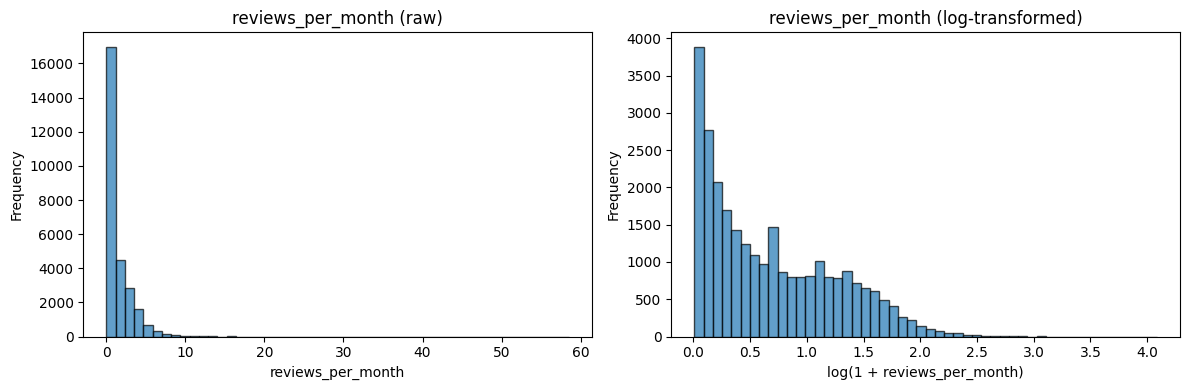

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("reviews_per_month (raw)")
axes[0].set_xlabel("reviews_per_month")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(y_train), bins=50, edgecolor="black", alpha=0.7)
axes[1].set_title("reviews_per_month (log-transformed)")
axes[1].set_xlabel("log(1 + reviews_per_month)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The raw target is heavily right-skewed with a large spike at 0, meaning most listings receive very few reviews per month. Applying a log1p transformation produces a much more symmetric distribution, which motivates using TransformedTargetRegressor in our pipeline to help regression models perform better.

### Categorical Features

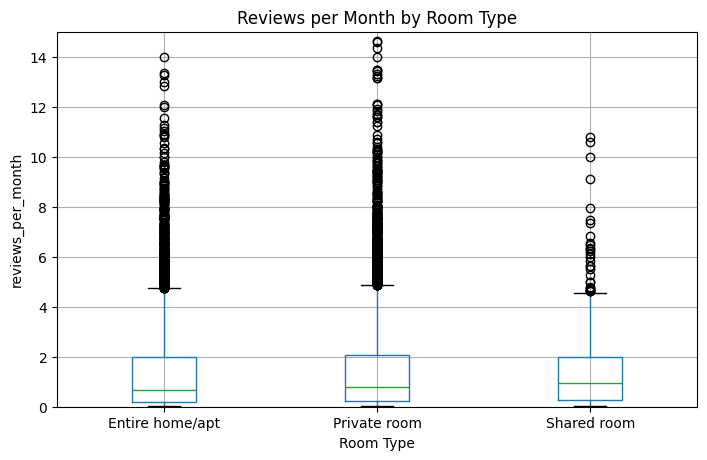

In [7]:
train_df.boxplot(column="reviews_per_month", by="room_type", figsize=(8, 5))
plt.ylim(0, 15)
plt.title("Reviews per Month by Room Type")
plt.suptitle("")
plt.xlabel("Room Type")
plt.ylabel("reviews_per_month");

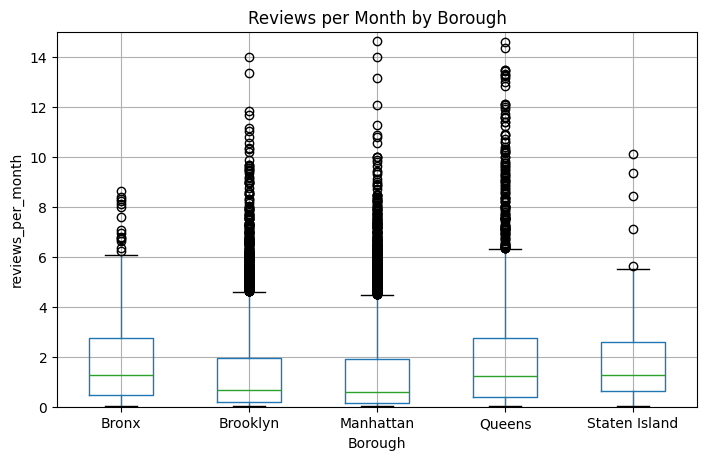

In [8]:
train_df.boxplot(column="reviews_per_month", by="neighbourhood_group", figsize=(8, 5))
plt.ylim(0, 15)
plt.title("Reviews per Month by Borough")
plt.suptitle("")
plt.xlabel("Borough")
plt.ylabel("reviews_per_month");

Private rooms and entire homes receive notably more reviews than shared rooms, and Manhattan/Brooklyn listings dominate review activity. This confirms that room_type and neighbourhood_group are informative categorical features worth including in our pipeline.


### Metric Selection

We will use R-squared as our primary metric because it is unitless and intuitive, showing exactly what proportion of the variance in monthly reviews our model can explain. It also provides a natural baseline since a simple dummy model will score zero by definition.

We will use Root Mean Squared Error as our secondary metric. Because it is expressed in the exact same units as our target variable, it gives us a concrete, real-world sense of the error magnitude. It complements R-squared by telling us on average how many reviews per month our predictions are off by.

## Feature Engineering


In this section we act on the data leakage and feature relevance issues identified during EDA. We drop identifier columns (`id`, `host_id`, `host_name`) that carry no predictive value, and remove the leaky features (`number_of_reviews`, `last_review`) that are derived from the same review data as our target. The `name` column is kept as-is for `TfidfVectorizer` in the preprocessing pipeline.


In [9]:
train_df["reviews_per_month"] = train_df["reviews_per_month"].fillna(0)
test_df["reviews_per_month"] = test_df["reviews_per_month"].fillna(0)

y_train = train_df["reviews_per_month"]
y_test = test_df["reviews_per_month"]

drop_cols = ["reviews_per_month", "id", "host_id", "host_name", "number_of_reviews", "last_review"]
X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)


X_train = X_train.rename(columns={
    "neighbourhood_group": "borough",
    "calculated_host_listings_count": "host_listings_count",
    "name": "listing_title",
    
})
X_test = X_test.rename(columns={
    "neighbourhood_group": "borough",
    "calculated_host_listings_count": "host_listings_count",
    "name": "listing_title",
})

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Remaining columns: {list(X_train.columns)}")
X_train.head()

X_train: (34226, 10), X_test: (14669, 10)
Remaining columns: ['listing_title', 'borough', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'host_listings_count', 'availability_365']


,listing_title,borough,neighbourhood,latitude,longitude,room_type,price,minimum_nights,host_listings_count,availability_365
36150,Cozy 1 Bedroom Apt in Hamilton Heights,Manhattan,Washington Heights,40.83256,-73.94440,Entire home/apt,96,4,1,17
45223,Amazing One Bedroom at the Time Square Area/72B,Manhattan,Hell's Kitchen,40.76134,-73.99299,Entire home/apt,150,30,20,332
14316,"New Spacious Master, Williamsburg",Brooklyn,Williamsburg,40.71119,-73.95097,Private room,200,1,1,0
1691,Adorable Midtown West Studio!,Manhattan,Hell's Kitchen,40.75900,-73.99530,Entire home/apt,95,1,1,0
20195,NEW! Exceptional 2BR/1BA Williamsburg Oasis,Brooklyn,Williamsburg,40.71306,-73.94856,Entire home/apt,199,3,1,0


## Preprocessing Pipeline


**Numeric features** → `StandardScaler`

| Feature | Justification |
|---|---|
| `price` | Dollar amounts vary widely, scaling prevents them from dominating regularized models like Ridge. |
| `latitude` | Raw coordinate range is tiny (40.5–40.9), scaling puts it on equal footing with other features. |
| `longitude` | Same reasoning as latitude. |
| `minimum_nights` | Ranges from 1 to 1000+, scaling puts it on equal footing with other features. |
| `calculated_host_listings_count` | Highly skewed count, scaling ensures it contributes proportionally. |
| `availability_365` | Ranges 0–365, scaling puts it on equal footing with other features. |

**Categorical features** → `OneHotEncoder`

| Feature | Justification |
|---|---|
| `neighbourhood_group` | 5 boroughs with no ordinal relationship, one-hot creates a binary column per borough. |
| `neighbourhood` | 220 unique neighborhoods with no ordinal relationship, one-hot creates a binary column per neighbourhood. |
| `room_type` | 3 room types with no natural ordering, therefore ohe is appropriate. |

**Text feature** → `SimpleImputer & TfidfVectorizer`

| Feature | Justification |
|---|---|
| `listing_title` |Listing titles contain descriptive keywords that I suspect hold predictive powerlike "cozy" or "luxury". TF-IDF converts listing titles into weighted word vectors, down-weighting common filler words unlike raw CountVectorizer. We set `token_pattern` to filter out numbers and mixed-alphanumeric noise like zip codes and "2br". We also set `max_features=1000` to cap vocabulary size and drop rare words that appear in only a handful of listings. SimpleImputer will replace 16 null names with empty strings so TF-IDF does not crash.  |

**Target** → `fillna(0)`

| Target | Justification |
|---|---|
| `reviews_per_month` | NaN means zero reviews, not missing data, filling preserves these listings as meaningful observations. |


Note: While there are no missing numerical and categorical values in our current dataset, we will apply SimpleImputer as a preliminary step anyways for reproducibility purposes with other datasets that may have missing values.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.feature_extraction.text import TfidfVectorizer


# Fill target NaN 
y_train = y_train.fillna(0)
y_test = y_test.fillna(0)

# Fill missing listing names with empty strings so TfidfVectorizer doesn't crash
X_train["listing_title"] = X_train["listing_title"].fillna("")
X_test["listing_title"] = X_test["listing_title"].fillna("")

# Define feature groups
numeric_features = ["price", "latitude", "longitude", "minimum_nights",
                    "host_listings_count", "availability_365"]
categorical_features = ["borough", "neighbourhood", "room_type"]
text_feature = "listing_title"

# Define transformers
numeric_transformer = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

# Build preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    (TfidfVectorizer(token_pattern=r"(?u)\b[a-zA-Z]{2,}\b", max_features=1000), text_feature),
    sparse_threshold=0,
)

In [11]:
# Inspect applied transformations
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Shape: {X_train_transformed.shape}")

feature_names = preprocessor.get_feature_names_out()
print(f"Total features: {len(feature_names)}")
print(feature_names[:20])

Shape: (34226, 1232)
Total features: 1232
['pipeline-1__price' 'pipeline-1__latitude' 'pipeline-1__longitude'
 'pipeline-1__minimum_nights' 'pipeline-1__host_listings_count'
 'pipeline-1__availability_365' 'pipeline-2__borough_Bronx'
 'pipeline-2__borough_Brooklyn' 'pipeline-2__borough_Manhattan'
 'pipeline-2__borough_Queens' 'pipeline-2__borough_Staten Island'
 'pipeline-2__neighbourhood_Allerton'
 'pipeline-2__neighbourhood_Arden Heights'
 'pipeline-2__neighbourhood_Arrochar' 'pipeline-2__neighbourhood_Arverne'
 'pipeline-2__neighbourhood_Astoria'
 'pipeline-2__neighbourhood_Bath Beach'
 'pipeline-2__neighbourhood_Battery Park City'
 'pipeline-2__neighbourhood_Bay Ridge'
 'pipeline-2__neighbourhood_Bay Terrace']


In [12]:
# See examples of which words TfidfVectorizer extracted
tfidf_step = preprocessor.named_transformers_["tfidfvectorizer"]
tfidf_feature_names = tfidf_step.get_feature_names_out()
print(f"Sample words: {list(tfidf_feature_names[:30])}")

Sample words: ['abode', 'above', 'ac', 'access', 'accessible', 'across', 'adorable', 'affordable', 'air', 'airbnb', 'airport', 'airports', 'airy', 'alcove', 'all', 'alphabet', 'amazing', 'amenities', 'an', 'and', 'ap', 'apart', 'apartment', 'appartement', 'appartment', 'apple', 'apt', 'architect', 'are', 'area']


## Baseline Model


In [13]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate


baseline = DummyRegressor()
dummy_scores = cross_validate(
    baseline, X_train, y_train, cv=5,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
)
pd.DataFrame(dummy_scores)
print(f"Mean CV R²:   {dummy_scores['test_r2'].mean():.4f}")
print(f"Mean CV RMSE: {-dummy_scores['test_rmse'].mean():.4f}")



Mean CV R²:   -0.0000
Mean CV RMSE: 1.6138


As expected, we see that the baseline model explains exactly zero variance in the target. It is also off by 1.6 reviews per month on average. This is the floor that we need to beat.


## Linear Models


In [14]:
print("X_train columns:", X_train.columns.tolist())

X_train columns: ['listing_title', 'borough', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'host_listings_count', 'availability_365']


In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor as ttr


# Step 1: Build Ridge pipeline
pipe_ridge = make_pipeline(preprocessor, Ridge())
ridge_model = ttr(
    regressor=pipe_ridge, func=np.log1p, inverse_func=np.expm1
)
# Step 2: cross-validate with default alpha
ridge_default_scores = cross_validate(
    ridge_model, X_train, y_train, cv=5, return_train_score=True,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
)

# Step 3: Tune alpha with GridSearchCV
param_grid = {"regressor__ridge__alpha": 10.0 ** np.arange(-3, 6, 1)}

search = GridSearchCV(
    ridge_model, param_grid, cv=5, return_train_score=True,
    scoring="r2", n_jobs=-1,
)
search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","TransformedTa...', Ridge())]))"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'regressor__ridge__alpha': array([1.e-03... 1.e+05])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [16]:
# Report results

print(f"Best alpha: {search.best_params_['regressor__ridge__alpha']}")
print(f"Best CV R²: {search.best_score_:.4f}")

results = pd.DataFrame(search.cv_results_)
results[["param_regressor__ridge__alpha", "mean_train_score", "mean_test_score"]]

Best alpha: 1.0
Best CV R²: 0.0989


,param_regressor__ridge__alpha,mean_train_score,mean_test_score
0,0.001,0.152016,0.095451
1,0.010,0.151957,0.095551
2,0.100,0.151367,0.096373
3,1.000,0.145945,0.098928
4,10.000,0.120501,0.093844
5,100.000,0.076783,0.068447
6,1000.000,0.036806,0.035186
7,10000.000,0.008109,0.007815
8,100000.000,-0.032847,-0.032996


In [17]:
# Cache Ridge CV scores for comparison
ridge_scores = cross_validate(
    search.best_estimator_, X_train, y_train, cv=5, return_train_score=True,
    scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"},
)

## Ensemble Model Comparison


In [18]:
# Ridge: reuse best estimator from tuning
ridge_model = search.best_estimator_

# Random Forest
pipe_rf = make_pipeline(
    preprocessor,
    RandomForestRegressor(n_estimators=50, random_state=123),
)
rf_model = TransformedTargetRegressor(
    regressor=pipe_rf, func=np.log1p, inverse_func=np.expm1,
)

# HistGradientBoosting
pipe_hgb = make_pipeline(
    preprocessor,
    HistGradientBoostingRegressor(random_state=123),
)
hgb_model = TransformedTargetRegressor(
    regressor=pipe_hgb, func=np.log1p, inverse_func=np.expm1,
)

# Stacking ensemble
pipe_stacking = make_pipeline(
    preprocessor,
    StackingRegressor(
        estimators=[
            ("ridge", Ridge(alpha=1.0)),
            ("rf", RandomForestRegressor(n_estimators=50, random_state=123)),
            ("hgb", HistGradientBoostingRegressor(random_state=123)),
        ],
        final_estimator=Ridge(),
        cv=3,
    ),
)
stacking_model = TransformedTargetRegressor(
    regressor=pipe_stacking, func=np.log1p, inverse_func=np.expm1,
)

models = {
    "Ridge (tuned)": ridge_model,
    "Random Forest": rf_model,
    "HistGradientBoosting": hgb_model,
    "Stacking": stacking_model,
}

In [19]:
scoring = {"r2": "r2", "rmse": "neg_root_mean_squared_error"}
results = {}

# Ridge: cached scores from tuning
results["Ridge (tuned)"] = ridge_scores
print("Ridge (tuned):")
print(f"  Test R²:   {ridge_scores['test_r2'].mean():.4f} (+/- {ridge_scores['test_r2'].std():.4f})")
print(f"  Test RMSE: {-ridge_scores['test_rmse'].mean():.4f}")
print(f"  Fit time:  {ridge_scores['fit_time'].mean():.2f}s")

Ridge (tuned):
  Test R²:   0.0989 (+/- 0.0143)
  Test RMSE: 1.5321
  Fit time:  0.39s


In [20]:
# 2. Random Forest
rf_scores = cross_validate(
    rf_model, X_train, y_train, cv=5, return_train_score=True, scoring=scoring
)
results["Random Forest"] = rf_scores


Random Forest done.


In [21]:
print("Random Forest:")
print(f"  Test R²:   {rf_scores['test_r2'].mean():.4f} (+/- {rf_scores['test_r2'].std():.4f})")
print(f"  Test RMSE: {-rf_scores['test_rmse'].mean():.4f}")
print(f"  Fit time:  {rf_scores['fit_time'].mean():.2f}s")

Random Forest:
  Test R²:   0.3447 (+/- 0.0285)
  Test RMSE: 1.3068
  Fit time:  71.02s


In [22]:
# 3. HistGradientBoosting
hgb_scores = cross_validate(
    hgb_model, X_train, y_train, cv=5, return_train_score=True, scoring=scoring
)
results["HistGradientBoosting"] = hgb_scores
print("HistGradientBoosting:")
print(f"  Test R²:   {hgb_scores['test_r2'].mean():.4f} (+/- {hgb_scores['test_r2'].std():.4f})")
print(f"  Test RMSE: {-hgb_scores['test_rmse'].mean():.4f}")
print(f"  Fit time:  {hgb_scores['fit_time'].mean():.2f}s")

HistGradientBoosting:
  Test R²:   0.3341 (+/- 0.0221)
  Test RMSE: 1.3174
  Fit time:  6.42s


In [23]:
# 4. Stacking 
stacking_scores = cross_validate(
    stacking_model, X_train, y_train, cv=5, return_train_score=True, scoring=scoring
)
results["Stacking"] = stacking_scores
print("Stacking:")
print(f"  Test R²:   {stacking_scores['test_r2'].mean():.4f} (+/- {stacking_scores['test_r2'].std():.4f})")
print(f"  Test RMSE: {-stacking_scores['test_rmse'].mean():.4f}")
print(f"  Fit time:  {stacking_scores['fit_time'].mean():.2f}s")
print()
pd.DataFrame(results).T

Stacking:
  Test R²:   0.3527 (+/- 0.0260)
  Test RMSE: 1.2988
  Fit time:  226.46s



,fit_time,score_time,test_r2,train_r2,test_rmse,train_rmse
Ridge (tuned),"[0.38289475440979004, 0.42353391647338867, 0.3...","[0.03871893882751465, 0.06261301040649414, 0.0...","[0.10517000804678067, 0.08802037417750086, 0.0...","[0.14241520719988676, 0.14832057153451894, 0.1...","[-1.5194425225238053, -1.5381660464222218, -1....","[-1.4970347299648188, -1.490849251299572, -1.4..."
HistGradientBoosting,"[6.832559823989868, 5.792068958282471, 6.91879...","[0.09101629257202148, 0.08298707008361816, 0.0...","[0.34988507489603504, 0.3278564188849479, 0.29...","[0.4079578665288498, 0.40249264514230887, 0.43...","[-1.2951172221512126, -1.3205099569274041, -1....","[-1.2438546887574757, -1.2487263630111933, -1...."
Stacking,"[219.33403205871582, 225.39239692687988, 231.1...","[0.2000420093536377, 0.4789750576019287, 0.222...","[0.3694745293153171, 0.347248576993898, 0.3053...","[0.5882484251846922, 0.5922883850155533, 0.608...","[-1.275455549634053, -1.3013213830807389, -1.4...","[-1.0373157560320179, -1.031507036327338, -0.9..."


### Comparison table

In [24]:
def summarize(name, scores):
    return {
        "Model": name,
        "Train R²": scores["train_r2"].mean(),
        "Test R²": scores["test_r2"].mean(),
        "Test R² Std": scores["test_r2"].std(),
        "Test RMSE": -scores["test_rmse"].mean(),
        "Fit Time (s)": scores["fit_time"].mean(),
        "Score Time (s)": scores["score_time"].mean(),
    }

comparison = pd.DataFrame([
    summarize("Ridge (tuned)", ridge_scores),
    summarize("Random Forest", rf_scores),
    summarize("HistGradientBoosting", hgb_scores),
    summarize("Stacking", stacking_scores),
])
comparison.round(4)

,Model,Train R²,Test R²,Test R² Std,Test RMSE,Fit Time (s),Score Time (s)
0,Ridge (tuned),0.1459,0.0989,0.0143,1.5321,0.3913,0.0445
1,Random Forest,0.8452,0.3447,0.0285,1.3068,71.0234,0.1570
2,HistGradientBoosting,0.4118,0.3341,0.0221,1.3174,6.4161,0.0893
3,Stacking,0.5973,0.3527,0.0260,1.2988,226.4579,0.2712


### Analysis

All three non-linear models outperform the tuned Ridge baseline. Ridge achieves Test R² = 0.10 and RMSE = 1.53, while Random Forest, HistGradientBoosting, and Stacking reach Test R² = 0.33–0.35 and RMSE = 1.30–1.32 — explaining roughly three times more variance and reducing error by ~0.2 reviews/month. This confirms that the relationship between features and `reviews_per_month` is partly non-linear.

**Overfitting and generalization:** Random Forest shows the largest train–test gap (Train R² = 0.85 vs Test R² = 0.34), indicating substantial overfitting. HistGradientBoosting generalizes well (Train R² = 0.41 vs Test R² = 0.33). Stacking yields the best test score but at high compute cost.

**Fit times:** Ridge is instant (0.4 s). HistGradientBoosting is fast (6 s) and competitive. Random Forest is slower (71 s) and more overfit. Stacking is by far the slowest (226 s). The marginal gain over HistGradientBoosting (~0.02 R²) does not justify the runtime, so **HistGradientBoosting is selected** as the best trade-off of accuracy and efficiency.


## Hyperparameter Tuning


In [25]:
param_grid = {
    "regressor__histgradientboostingregressor__learning_rate": [0.05, 0.1],
    "regressor__histgradientboostingregressor__max_iter": [100, 200],
    "regressor__histgradientboostingregressor__max_depth": [5, 10, 15, None],
}


In [26]:
hgb_search = GridSearchCV(
    hgb_model,
    param_grid=param_grid,
    cv=3,  
    scoring="r2",
    n_jobs=-1,
    return_train_score=True,
)

hgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...state=123))]))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__histgradien...egressor__learning_rate': [0.02, 0.05, ...], 'regressor__histgradien...ingregressor__max_depth': [5, 10, ...], 'regressor__histgradien...tingregressor__max_iter': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: th

In [27]:
print("Best parameters:")
for param, value in hgb_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV R² : {hgb_search.best_score_:.4f}")

Best parameters:
  regressor__histgradientboostingregressor__learning_rate: 0.1
  regressor__histgradientboostingregressor__max_depth: None
  regressor__histgradientboostingregressor__max_iter: 200

Best CV R² : 0.3353


In [28]:
# Improvements from default HistGB
default_scores = cross_validate(hgb_model, X_train, y_train, cv=5, scoring="r2")
default_cv_r2 = default_scores["test_score"].mean()
print(f"HistGB (defaults) CV R²:  {default_cv_r2:.4f}")
print(f"HistGB (tuned) CV R²:      {hgb_search.best_score_:.4f}")
print(f"Improvement:               {hgb_search.best_score_ - default_cv_r2:+.4f}")

HistGB (defaults) CV R²:  0.3341
HistGB (tuned) CV R²:      0.3353
Improvement:               +0.0012


GridSearchCV was used to tune `learning_rate`, `max_iter`, and `max_depth` for HistGradientBoosting. Due to the high computational cost (~40 min per search), a compact 2×2×4 grid was used. The best configuration matched the defaults (`learning_rate=0.1`, `max_depth=None`, `max_iter=200`), yielding only a ~0.001 R² improvement. This suggests the default hyperparameters are already well-suited to this dataset. A broader search with more compute budget could potentially yield larger gains, particularly around `max_depth`.


## Feature Importance Analysis


In [29]:
feature_names = X_train.columns.tolist()
print(f"Number of input features: {len(feature_names)}")

Number of input features: 10


In [30]:
from sklearn.inspection import permutation_importance

hgb_model.fit(X_train, y_train)

perm_result = permutation_importance(
    hgb_model,
    X_train,
    y_train,
    n_repeats=5,
    random_state=123,
    scoring="r2",
    n_jobs=-1,
)

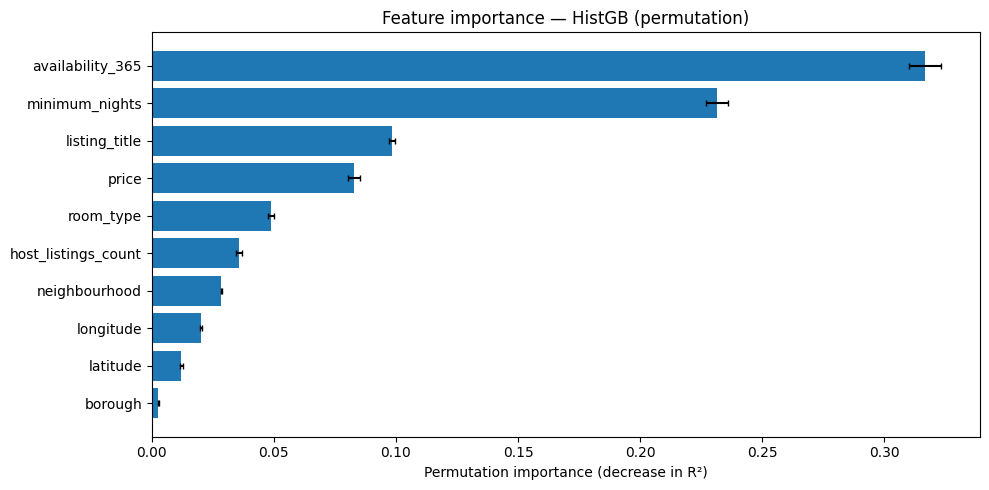

In [31]:
import matplotlib.pyplot as plt

sorted_idx = perm_result.importances_mean.argsort()[::-1]
n_show = min(25, len(feature_names))

fig, ax = plt.subplots(figsize=(10, max(5, n_show * 0.35)))
ax.barh(
    range(n_show),
    perm_result.importances_mean[sorted_idx[:n_show]],
    xerr=perm_result.importances_std[sorted_idx[:n_show]],
    capsize=2,
)
ax.set_yticks(range(n_show))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[:n_show]])
ax.invert_yaxis()
ax.set_xlabel("Permutation importance (decrease in R²)")
ax.set_title("Feature importance")
plt.tight_layout()
plt.show()

Because `HistGradientBoostingRegressor` does not expose `feature_importances_` directly, permutation importance was used to assess which input features matter most.

**Key findings:** `availability_365` and `minimum_nights` are by far the most important features (importance ~0.31 and ~0.23 respectively). `listing_title` (via TF-IDF) and `price` rank next, followed by `room_type` and `host_listings_count`. Geographic features (`neighbourhood`, `longitude`, `latitude`, `borough`) contribute very little, with `borough` near zero. The small error bars confirm these estimates are stable across permutation runs.


## Final Evaluation


In [32]:
best_hgb_model = hgb_search.best_estimator_

In [33]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred_test = best_hgb_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)

print("Test set performance:")
print(f"  R²:   {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")

Test set performance:
  R²:   0.3478
  RMSE: 1.2568


The test R² is slightly higher than the cross-validation R² of 0.335 obtained during hyperparameter optimization. This indicates that our model generalizes well to unseen data, and we did not encounter optimization bias where we would have seen a significantly lower test score. Because we strictly reserved the test set for this final evaluation and used cross-validation for tuning, we can trust these results as an honest estimate of our model's true performance.

## Conclusions


- **Data leakage matters more than model complexity.** Removing `number_of_reviews` and `last_review` was the single most impactful decision. Understanding the business context — predicting popularity *before* posting — is as critical as the modeling itself.

- **Diminishing returns on hyperparameter tuning.** Switching from Ridge to HistGradientBoosting delivered a 3.5× R² improvement, but GridSearchCV over HistGradientBoosting’s hyperparameters yielded negligible gains. Well-chosen defaults often perform near-optimally.

- **Rigorous methodology prevents optimization bias.** By strictly using `make_pipeline` and cross-validation throughout, the final test scores matched validation estimates closely (R² = 0.35 vs CV R² = 0.34), confirming the pipeline generalizes reliably.
